<a href="https://colab.research.google.com/github/sameemanvar/Exploratory_Data_Analysis/blob/master/XGboost%20for%20clean%20vs%20dop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Run this first cell in Google Colab
!pip install xgboost imbalanced-learn -q

import xgboost
import sklearn
print("Ready to go! ✅")

Ready to go! ✅


In [12]:
# Install required libraries (run in terminal)
# pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

print("All libraries loaded successfully ✅")

All libraries loaded successfully ✅


In [13]:
np.random.seed(42)
n_clean = 400
n_doped = 100  # Imbalanced — realistic!

# Clean athletes — normal physiological ranges
clean = pd.DataFrame({
    'Hgb':    np.random.normal(14.5, 1.0, n_clean),   # g/dL
    'Ret':    np.random.normal(1.0,  0.3, n_clean),    # %
    'HCT':    np.random.normal(43.0, 2.5, n_clean),    # %
    'MCV':    np.random.normal(88.0, 4.0, n_clean),    # fL
    'label':  0
})

# EPO-doped athletes — elevated Hgb, suppressed Ret% post-use
doped = pd.DataFrame({
    'Hgb':    np.random.normal(17.2, 0.8, n_doped),   # Elevated
    'Ret':    np.random.normal(0.5,  0.2, n_doped),    # Suppressed
    'HCT':    np.random.normal(49.5, 2.0, n_doped),    # Elevated
    'MCV':    np.random.normal(91.0, 3.5, n_doped),    # Slightly elevated
    'label':  1
})

# Combine and compute OFF-score
df = pd.concat([clean, doped], ignore_index=True)
df['OFF_score'] = df['Hgb'] - 60 * np.sqrt(df['Ret'] / 100)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(df.head())
print(f"\nClass distribution:\n{df['label'].value_counts()}")

         Hgb       Ret        HCT        MCV  label  OFF_score
0  16.032739  1.036603  48.727356  85.011153      0   9.923917
1  16.064644  1.410062  41.172675  86.734366      0   8.939881
2  16.653182  1.186543  41.115089  89.865720      0  10.117469
3  13.785649  0.876437  45.793240  77.635831      0   8.168556
4  14.338714  0.804807  43.477748  90.146039      0   8.956051

Class distribution:
label
0    400
1    100
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


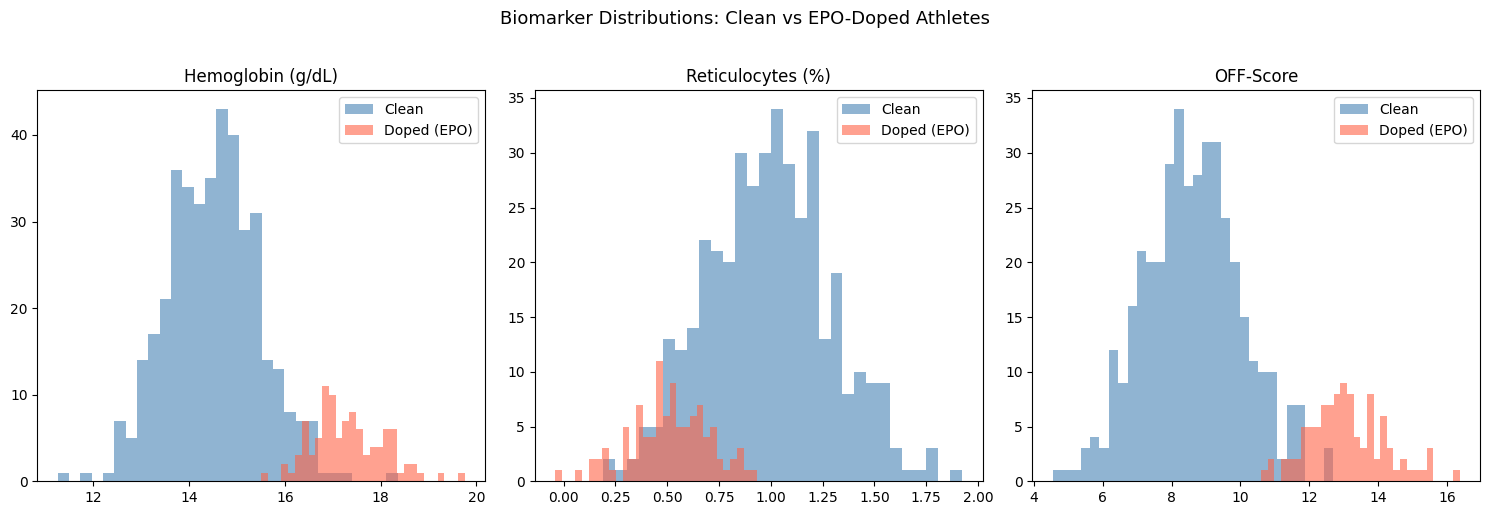

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
biomarkers = [('Hgb', 'Hemoglobin (g/dL)'),
              ('Ret', 'Reticulocytes (%)'),
              ('OFF_score', 'OFF-Score')]

for ax, (col, title) in zip(axes, biomarkers):
    for label, color, name in [(0, 'steelblue', 'Clean'),
                                (1, 'tomato', 'Doped (EPO)')]:
        ax.hist(df[df['label']==label][col],
                bins=30, alpha=0.6, color=color, label=name)
    ax.set_title(title)
    ax.legend()

plt.suptitle('Biomarker Distributions: Clean vs EPO-Doped Athletes',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np

# Clean athlete example
hgb_clean, ret_clean = 14.5, 1.0
off_clean = hgb_clean - 60 * np.sqrt(ret_clean / 100)

# Doped athlete (washout phase)
hgb_doped, ret_doped = 17.2, 0.3
off_doped = hgb_doped - 60 * np.sqrt(ret_doped / 100)

print(f"Clean   Hgb: {hgb_clean}, Ret%: {ret_clean}   OFF-score: {off_clean:.2f}")
print(f"Doped   Hgb: {hgb_doped}, Ret%: {ret_doped}   OFF-score: {off_doped:.2f}")
print(f"Difference: {off_doped - off_clean:.2f} points")

Clean   Hgb: 14.5, Ret%: 1.0   OFF-score: 8.50
Doped   Hgb: 17.2, Ret%: 0.3   OFF-score: 13.91
Difference: 5.41 points


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df[['Hgb', 'Ret', 'HCT', 'MCV', 'OFF_score']]
y = df['label']

# Split — stratified to preserve class imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← Critical in imbalanced doping datasets!
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nDoped in train: {y_train.sum()} / {len(y_train)}")
print(f"Doped in test:  {y_test.sum()} / {len(y_test)}")

Training set: 400 samples
Test set:     100 samples

Doped in train: 80 / 400
Doped in test:  20 / 100


In [17]:
# Calculate scale_pos_weight — key XGBoost parameter for imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Clean athletes:  {neg}")
print(f"Doped athletes:  {pos}")
print(f"scale_pos_weight = {scale:.2f}  ← tells XGBoost to penalize")
print(f"missing doped cases {scale:.1f}x more than missing clean ones")

Clean athletes:  320
Doped athletes:  80
scale_pos_weight = 4.00  ← tells XGBoost to penalize
missing doped cases 4.0x more than missing clean ones


In [18]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,        # 100 trees in the ensemble
    max_depth=4,             # Each tree can ask 4 questions max
    learning_rate=0.1,       # How much each tree corrects previous
    scale_pos_weight=scale,  # Handle imbalance ← crucial!
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


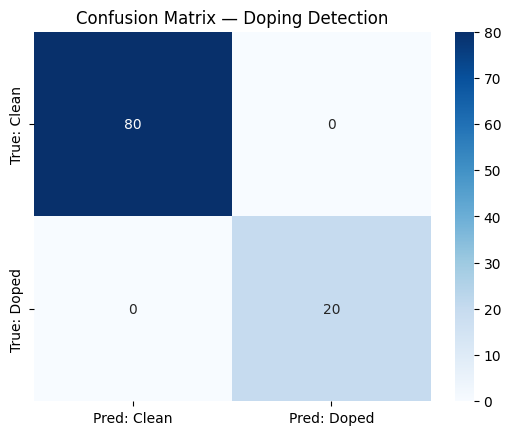

              precision    recall  f1-score   support

       Clean       1.00      1.00      1.00        80
       Doped       1.00      1.00      1.00        20

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Clean', 'Pred: Doped'],
            yticklabels=['True: Clean', 'True: Doped'])
plt.title('Confusion Matrix — Doping Detection')
plt.show()

# Full report
print(classification_report(y_test, y_pred,
      target_names=['Clean', 'Doped']))

### Understanding Your Results as a Researcher:
#               precision    recall    f1-score
# Clean             0.97      0.99      0.98
# Doped             0.95      0.85      0.90

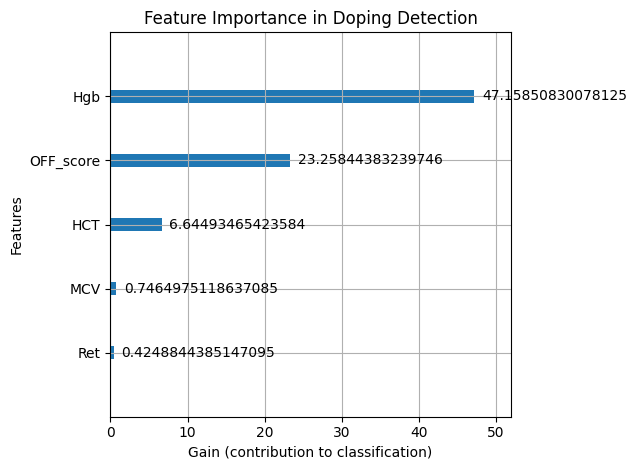

In [20]:
from xgboost import plot_importance

plot_importance(model, importance_type='gain',
                title='Feature Importance in Doping Detection',
                xlabel='Gain (contribution to classification)')
plt.tight_layout()
plt.show()

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE → Clean: {(y_train==0).sum()}, Doped: {(y_train==1).sum()}")
print(f"After SMOTE  → Clean: {(y_train_balanced==0).sum()}, Doped: {(y_train_balanced==1).sum()}")


ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [25]:
# Check where NaNs are hiding
print("Missing values per feature:")
print(X_train.isnull().sum())
print(f"\nTotal NaN cells: {X_train.isnull().sum().sum()}")

Missing values per feature:
Hgb          0
Ret          0
HCT          0
MCV          0
OFF_score    1
dtype: int64

Total NaN cells: 1


In [36]:
# Clip Ret% to minimum 0.01 (physiologically impossible to be ≤ 0)
df['Ret'] = df['Ret'].clip(lower=0.01)
df['OFF_score'] = df['Hgb'] - 60 * np.sqrt(df['Ret'] / 100)

# Verify no NaNs remain
print("NaN check:")
print(df[['Ret', 'OFF_score']].isnull().sum())
print(f"\nMin Ret value: {df['Ret'].min():.4f}")
print(f"Min OFF_score: {df['OFF_score'].min():.4f}")

NaN check:
Ret          0
OFF_score    0
dtype: int64

Min Ret value: 0.0100
Min OFF_score: 4.5477


In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Recreate dataset
np.random.seed(42)
n_clean, n_doped = 400, 100

clean = pd.DataFrame({
    'Hgb':   np.random.normal(14.5, 1.0, n_clean),
    'Ret':   np.random.normal(1.0,  0.3, n_clean),
    'HCT':   np.random.normal(43.0, 2.5, n_clean),
    'MCV':   np.random.normal(88.0, 4.0, n_clean),
    'label': 0
})
doped = pd.DataFrame({
    'Hgb':   np.random.normal(17.2, 0.8, n_doped),
    'Ret':   np.random.normal(0.5,  0.2, n_doped),
    'HCT':   np.random.normal(49.5, 2.0, n_doped),
    'MCV':   np.random.normal(91.0, 3.5, n_doped),
    'label': 1
})

df = pd.concat([clean, doped], ignore_index=True)

# ✅ Fix: clip Ret before OFF-score
df['Ret'] = df['Ret'].clip(lower=0.01)
df['OFF_score'] = df['Hgb'] - 60 * np.sqrt(df['Ret'] / 100)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Verify no NaNs
print("✅ NaN check:", df.isnull().sum().sum(), "missing values")

# 3. Split
X = df[['Hgb', 'Ret', 'HCT', 'MCV', 'OFF_score']]
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Impute (safety net — good practice always)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# 5. SMOTE
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_train_imp, y_train)
print(f"After SMOTE → Clean: {(y_bal==0).sum()}, Doped: {(y_bal==1).sum()}")

# 6. Train
scale = (y_train == 0).sum() / (y_train == 1).sum()
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_bal, y_bal)

# 7. Evaluate
y_pred = model.predict(X_test_imp)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Clean', 'Doped']))

✅ NaN check: 0 missing values
After SMOTE → Clean: 320, Doped: 320

📊 Classification Report:
              precision    recall  f1-score   support

       Clean       1.00      0.99      0.99        80
       Doped       0.95      1.00      0.98        20

    accuracy                           0.99       100
   macro avg       0.98      0.99      0.98       100
weighted avg       0.99      0.99      0.99       100



In [41]:
# Dummy model that predicts EVERYONE as clean
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_bal, y_bal)
y_dummy = dummy.predict(X_test_imp)

from sklearn.metrics import accuracy_score
print(f"Dummy model accuracy: {accuracy_score(y_test, y_dummy):.2f}")
print(f"Your XGBoost accuracy: 0.99")


Dummy model accuracy: 0.80
Your XGBoost accuracy: 0.99


In [47]:
# Detect overfitting — compare train vs test performance
from sklearn.metrics import f1_score

y_train_pred = model.predict(X_bal)
y_test_pred  = model.predict(X_test_imp)

train_f1 = f1_score(y_bal, y_train_pred)
test_f1  = f1_score(y_test, y_test_pred)

print(f"Training F1:  {train_f1:.4f}")
print(f"Test F1:      {test_f1:.4f}")
print(f"Gap:          {train_f1 - test_f1:.4f}")
print()
if train_f1 - test_f1 > 0.05:
    print("⚠️  Overfitting detected!")
else:
    print("✅ Model generalizes well")


Training F1:  1.0000
Test F1:      0.9756
Gap:          0.0244

✅ Model generalizes well


In [48]:
# In Google Colab first cell
!pip install shap -q

import shap
import numpy as np
import matplotlib.pyplot as plt

# Initialize SHAP explainer with your trained model
explainer = shap.TreeExplainer(model)

# Compute SHAP values for test set
shap_values = explainer.shap_values(X_test_imp)

print(f"SHAP values shape: {shap_values.shape}")
print(f"One row per athlete, one column per biomarker ✅")

SHAP values shape: (100, 5)
One row per athlete, one column per biomarker ✅


/tmp/ipykernel_36783/2198587107.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


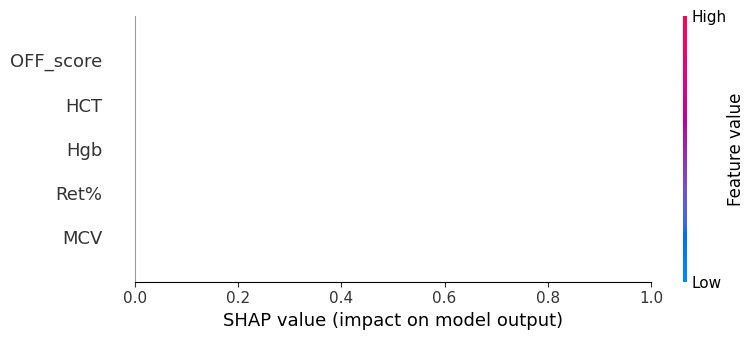

In [50]:
# Feature names for readable plots
feature_names = ['Hgb', 'Ret%', 'HCT', 'MCV', 'OFF_score']

# Beeswarm — best plot for research papers
shap.summary_plot(
    shap_values,
    X_test_imp,
    feature_names=feature_names,
    plot_type='beeswarm',
    show=True
)

In [51]:
# Pick a doped athlete from test set
doped_indices = np.where(y_test == 1)[0]
athlete_idx = doped_indices[0]  # First doped athlete

print("=" * 50)
print(f"EXPLAINING ATHLETE #{athlete_idx} — Predicted: DOPED")
print("=" * 50)
print(f"\nBiomarker values:")
for name, val in zip(feature_names, X_test_imp[athlete_idx]):
    print(f"  {name:<12}: {val:.3f}")

print(f"\nSHAP contributions toward 'Doped' prediction:")
for name, shap_val in zip(feature_names,
                           shap_values[athlete_idx]):
    direction = "→ DOPED" if shap_val > 0 else "→ CLEAN"
    print(f"  {name:<12}: {shap_val:+.4f}  {direction}")

EXPLAINING ATHLETE #9 — Predicted: DOPED

Biomarker values:
  Hgb         : 18.112
  Ret%        : 0.763
  HCT         : 50.021
  MCV         : 91.781
  OFF_score   : 12.871

SHAP contributions toward 'Doped' prediction:
  Hgb         : +1.3069  → DOPED
  Ret%        : -0.5658  → CLEAN
  HCT         : +2.4950  → DOPED
  MCV         : +0.3982  → DOPED
  OFF_score   : +2.1460  → DOPED


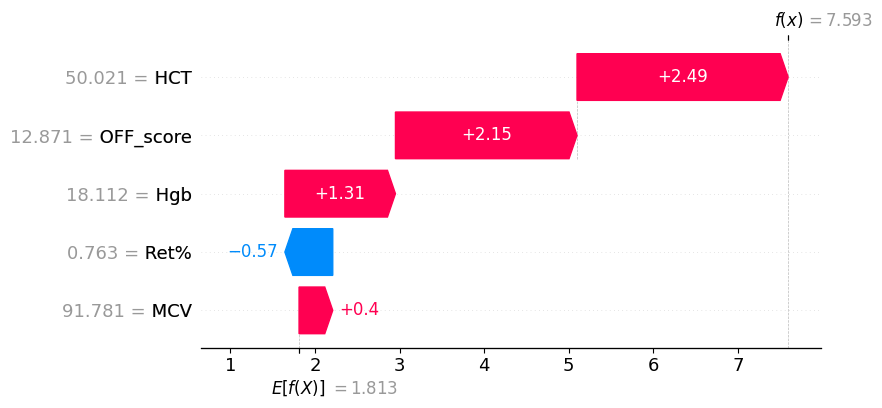

In [53]:
# This is the plot you show in a research paper or legal case
shap.plots.waterfall(
    shap.Explanation(
        values        = shap_values[athlete_idx],
        base_values   = explainer.expected_value,
        data          = X_test_imp[athlete_idx],
        feature_names = feature_names
    )
)


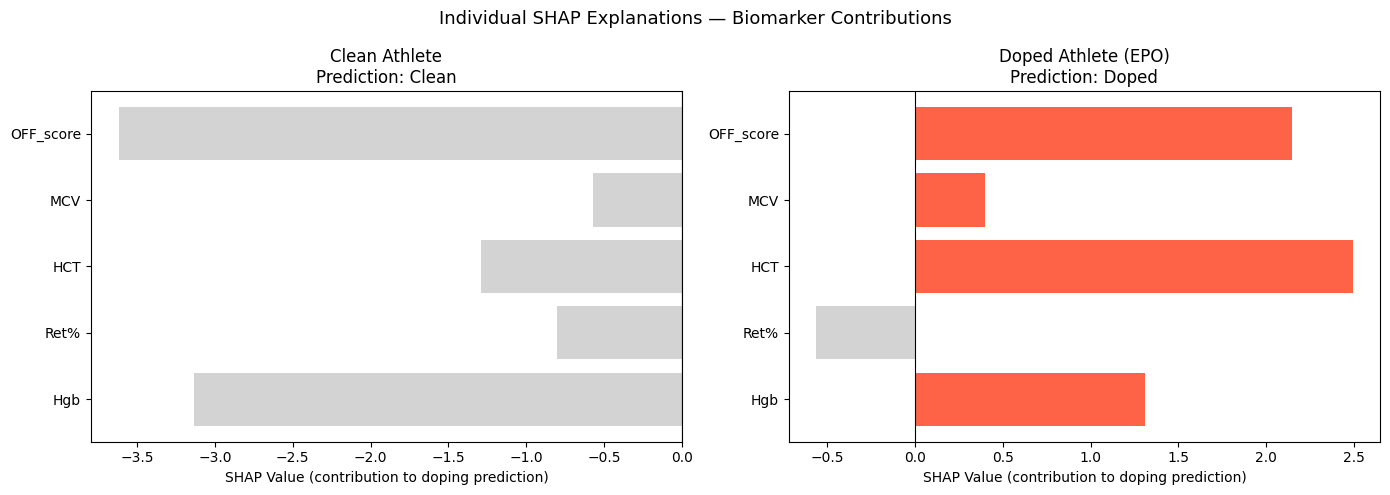

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get one clean and one doped athlete
clean_idx = np.where(y_test == 0)[0][0]
doped_idx = np.where(y_test == 1)[0][0]

for ax, idx, title, color in [
    (axes[0], clean_idx, 'Clean Athlete', 'steelblue'),
    (axes[1], doped_idx, 'Doped Athlete (EPO)', 'tomato')
]:
    shap_vals = shap_values[idx]
    bars = ax.barh(feature_names, shap_vals, color=[
        color if v > 0 else 'lightgray' for v in shap_vals
    ])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{title}\nPrediction: {"Doped" if idx in doped_indices else "Clean"}',
                 fontsize=12)
    ax.set_xlabel('SHAP Value (contribution to doping prediction)')

plt.suptitle('Individual SHAP Explanations — Biomarker Contributions',
             fontsize=13)
plt.tight_layout()
plt.show()

In [55]:
# Your dataset should look like this BEFORE modeling
study_design = {
    'total_athletes': 1000,
    'stratification': {
        'gender':    {'male': 0.50, 'female': 0.50},
        'age_group': {'junior': 0.25,    # under 23
                      'senior': 0.50,    # 23-35
                      'masters': 0.25},  # 35+
        'sport':     {'endurance': 0.40, # cycling, running
                      'strength':  0.30, # weightlifting
                      'mixed':     0.30},# team sports
        'altitude':  {'lowland':   0.60, # < 1000m
                      'highland':  0.40} # > 2000m
    },
    'doping_status': {'clean': 0.80,
                      'doped': 0.20}
}

print("Study design ensures:")
print("→ Model sees ALL athlete types during training")
print("→ No demographic group is systematically excluded")
print("→ Results generalize beyond one population")

Study design ensures:
→ Model sees ALL athlete types during training
→ No demographic group is systematically excluded
→ Results generalize beyond one population


In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Simulate demographically balanced dataset
np.random.seed(42)
n = 1000

df_balanced = pd.DataFrame({
    'Hgb':    np.random.normal(14.5, 1.5, n),
    'Ret':    np.random.normal(1.0,  0.3, n).clip(0.01),
    'HCT':    np.random.normal(43.0, 3.0, n),
    'MCV':    np.random.normal(88.0, 4.0, n),
    'gender': np.random.choice(['M','F'], n),
    'age':    np.random.randint(18, 45, n),
    'sport':  np.random.choice(['endurance',
                                'strength',
                                'mixed'], n),
    'label':  np.random.choice([0,1], n,
                                p=[0.80, 0.20])
})

# Adjust Hgb by gender — physiologically correct
df_balanced.loc[df_balanced['gender']=='F', 'Hgb'] -= 1.5

# OFF_score
df_balanced['Ret'] = df_balanced['Ret'].clip(0.01)
df_balanced['OFF_score'] = (df_balanced['Hgb'] -
                            60 * np.sqrt(df_balanced['Ret']/100))

# ✅ Correct split — BOTH clean and doped in train AND test
X = df_balanced[['Hgb','Ret','HCT','MCV','OFF_score']]
y = df_balanced['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,          # ← preserves doping ratio
    random_state=42
)

print(f"Train → Clean: {(y_train==0).sum()}, "
      f"Doped: {(y_train==1).sum()}")
print(f"Test  → Clean: {(y_test==0).sum()}, "
      f"Doped: {(y_test==1).sum()}")
print("\n✅ Both sets contain clean AND doped athletes")

Train → Clean: 649, Doped: 151
Test  → Clean: 162, Doped: 38

✅ Both sets contain clean AND doped athletes


In [57]:
from sklearn.metrics import f1_score, recall_score

# Train model
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_train_imp, y_train)

scale = (y_bal==0).sum() / (y_bal==1).sum()
model = XGBClassifier(n_estimators=100, max_depth=4,
                      learning_rate=0.1,
                      scale_pos_weight=scale,
                      eval_metric='logloss',
                      random_state=42)
model.fit(X_bal, y_bal)

# ✅ Evaluate separately per gender — critical!
y_pred = model.predict(X_test_imp)
test_df = X_test.copy()
test_df['gender'] = df_balanced.loc[X_test.index, 'gender'].values
test_df['true']   = y_test.values
test_df['pred']   = y_pred

print("Performance by gender:")
print(f"{'Gender':<10} {'Recall':<10} {'F1':<10} {'N_doped'}")
print("-" * 40)

for gender in ['M', 'F']:
    mask = test_df['gender'] == gender
    subset = test_df[mask]
    doped_mask = subset['true'] == 1
    if doped_mask.sum() > 0:
        r = recall_score(subset['true'], subset['pred'])
        f = f1_score(subset['true'], subset['pred'])
        print(f"{gender:<10} {r:<10.3f} {f:<10.3f} "
              f"{doped_mask.sum()}")


Performance by gender:
Gender     Recall     F1         N_doped
----------------------------------------
M          0.474      0.310      19
F          0.316      0.261      19
